<a href="https://colab.research.google.com/github/dnesgrgx/Machine-Learning-CMP364--Lab-reports/blob/main/Lab03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part A: Loading Dataset and displaying basic information

Task 1: Importing required libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Task 2: Loading the dataset provided in csv format.

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

Task 3: Displaying the Basic Information.

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Part B: Handling Missing Values

Task 4: Checking missing values.

In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Task 5: Visualizing the missing values in a heatmap.

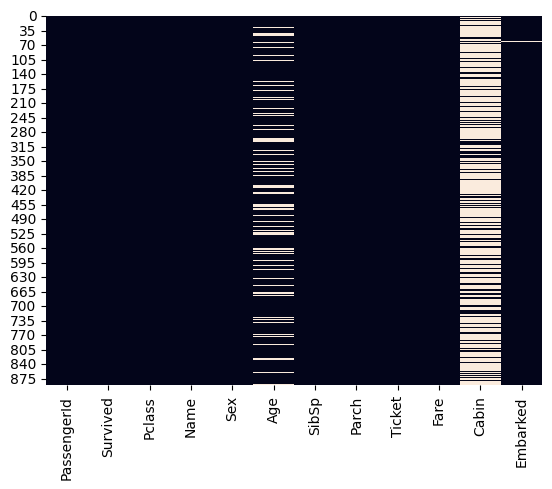

In [7]:
sns.heatmap(df.isnull(), cbar = False)
plt.show()

Task 6: Filling missing Age values with Median.

In [8]:
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipykernel_573/1933487976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [9]:
df['Age'].median()

28.0

In [10]:
df['Age'].value_counts()

,count
Age,
28.00,202
24.00,30
22.00,27
18.00,26
30.00,25
...,...
24.50,1
0.67,1
0.42,1


Task 7: Filling missing Embarked values with mode.

In [11]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_573/3744086084.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [12]:
df['Embarked'].mode()

,Embarked
0,S


In [13]:
df['Embarked'].value_counts()

,count
Embarked,
S,646
C,168
Q,77


Task 8: Droping Cabin column.

In [14]:
df.drop('Cabin', axis=1, inplace=True)

In [15]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


Part C: Encoding Categorical Variables

Task 9: Identifying categorical attributes.

In [16]:
df.select_dtypes(include='object').columns

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')

Task 10: Applying Label Encoding.

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Sex']=le.fit_transform(df['Sex'])

In [18]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,C


Task 11: Applying One-Hot Encoding

In [19]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [20]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,28.0,1,2,W./C. 6607,23.4500,False,True
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,False,False


Part D: Feature Scaling

Task 12: Selecting numerical columns.

In [21]:
num_cols = ['Age', 'Fare']

Task 13: Applying Standarization

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [23]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,-0.565736,1,0,A/5 21171,-0.502445,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,0.663861,1,0,PC 17599,0.786845,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,-0.258337,0,0,STON/O2. 3101282,-0.488854,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,0.433312,1,0,113803,0.420730,False,True
4,5,0,3,"Allen, Mr. William Henry",1,0.433312,0,0,373450,-0.486337,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,-0.181487,0,0,211536,-0.386671,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",0,-0.796286,0,0,112053,-0.044381,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,-0.104637,1,2,W./C. 6607,-0.176263,False,True
889,890,1,1,"Behr, Mr. Karl Howell",1,-0.258337,0,0,111369,-0.044381,False,False


Task 14: Observing transformed values.

In [24]:
df[['Age', 'Fare']].head()

,Age,Fare
0,-0.565736,-0.502445
1,0.663861,0.786845
2,-0.258337,-0.488854
3,0.433312,0.420730
4,0.433312,-0.486337


Part E: Outlier Detection

Task 15: Drawing boxplot.

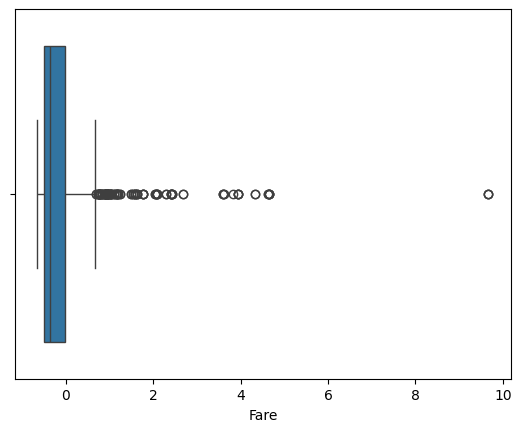

In [25]:
sns.boxplot(x=df['Fare'])
plt.show()

Task 16: Calculating Inter Quartile Range.

In [26]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper=Q3+1.5*IQR
print(f'Q1: {Q1}\nQ3: {Q3}\nIQR: {IQR}\nlower: {lower}\nupper: {upper}')

Q1: -0.4891482240181727
Q3: -0.024246350754841113
IQR: 0.4649018732633316
lower: -1.18650103391317
upper: 0.6731064591401562


Task 17: Finding outliers.

In [42]:
outliers = df[(df['Fare'] < lower) | (df['Fare'] > upper)]
print(len(outliers))

876


Part F: Feature Selection and Final Dataset

Task 18: Removing unnecessary columns.

In [29]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

In [30]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,-0.565736,1,0,-0.502445,False,True
1,1,1,0,0.663861,1,0,0.786845,False,False
2,1,3,0,-0.258337,0,0,-0.488854,False,True
3,1,1,0,0.433312,1,0,0.420730,False,True
4,0,3,1,0.433312,0,0,-0.486337,False,True
...,...,...,...,...,...,...,...,...,...
886,0,2,1,-0.181487,0,0,-0.386671,False,True
887,1,1,0,-0.796286,0,0,-0.044381,False,True
888,0,3,0,-0.104637,1,2,-0.176263,False,True
889,1,1,1,-0.258337,0,0,-0.044381,False,False


Task 19: Seperating features and target.

In [31]:
x = df.drop('Survived', axis=1)
print(x)

     Pclass  Sex       Age  SibSp  Parch      Fare  Embarked_Q  Embarked_S
0         3    1 -0.565736      1      0 -0.502445       False        True
1         1    0  0.663861      1      0  0.786845       False       False
2         3    0 -0.258337      0      0 -0.488854       False        True
3         1    0  0.433312      1      0  0.420730       False        True
4         3    1  0.433312      0      0 -0.486337       False        True
..      ...  ...       ...    ...    ...       ...         ...         ...
886       2    1 -0.181487      0      0 -0.386671       False        True
887       1    0 -0.796286      0      0 -0.044381       False        True
888       3    0 -0.104637      1      2 -0.176263       False        True
889       1    1 -0.258337      0      0 -0.044381       False       False
890       3    1  0.202762      0      0 -0.492378        True       False

[891 rows x 8 columns]


In [32]:
y = df['Survived']
print(y)

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64


Task 20: Checking final shape.

In [34]:
print(x.shape)

(891, 8)


In [35]:
print(y.shape)

(891,)


Additional Exercises

Exercise 1: Count the number of male and female passengers.

In [36]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [37]:
print(f'Male Count: {(df['Sex']=='male').sum()}')
print(f'Female Count: {(df['Sex']=='female').sum()}')

Male Count: 577
Female Count: 314


Exercise 2: Calculate average age before and after filling missing values.

In [38]:
print(f'Average age before filling missing values: {df['Age'].mean()}')

Average age before filling missing values: 29.69911764705882


In [39]:
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipykernel_573/1933487976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [40]:
print(f'Average age after filling missing values: {df['Age'].mean()}')

Average age after filling missing values: 29.36158249158249


Exercise 3: Detect outliers in the Age column.

In [43]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3-Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR
age_outliers = df[(df['Age'] < lower) | (df['Age'] > upper)]
print(age_outliers)
print(len(age_outliers))

     PassengerId  Survived  Pclass  \
7              8         0       3   
11            12         1       1   
15            16         1       2   
16            17         0       3   
33            34         0       2   
..           ...       ...     ...   
827          828         1       2   
829          830         1       1   
831          832         1       2   
851          852         0       3   
879          880         1       1   

                                              Name     Sex    Age  SibSp  \
7                   Palsson, Master. Gosta Leonard    male   2.00      3   
11                        Bonnell, Miss. Elizabeth  female  58.00      0   
15                Hewlett, Mrs. (Mary D Kingcome)   female  55.00      0   
16                            Rice, Master. Eugene    male   2.00      4   
33                           Wheadon, Mr. Edward H    male  66.00      0   
..                                             ...     ...    ...    ...   
827        

Exercise 4: Apply Min-Max Scaling instead of Standarization.

In [44]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
df[num_cols] = minmax.fit_transform(df[num_cols])

In [45]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,0.271174,1,0,A/5 21171,0.014151,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.472229,1,0,PC 17599,0.139136,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,0.321438,0,0,STON/O2. 3101282,0.015469,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.434531,1,0,113803,0.103644,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,0.434531,0,0,373450,0.015713,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,0.334004,0,0,211536,0.025374,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,0.233476,0,0,112053,0.058556,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,0.346569,1,2,W./C. 6607,0.045771,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,0.321438,0,0,111369,0.058556,C148,C


Exercise 5: Compare the results of Label Encoding and One-Hot-Encoding.

In [46]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Embarked_Label'] = le.fit_transform(df['Embarked'])

In [47]:
df_onehot = pd.get_dummies(df['Embarked'], drop_first=False)

In [48]:
comparison = pd.concat([df['Embarked'], df['Embarked_Label'], df_onehot], axis=1)
print(comparison.head())

  Embarked  Embarked_Label      C      Q      S
0        S               2  False  False   True
1        C               0   True  False  False
2        S               2  False  False   True
3        S               2  False  False   True
4        S               2  False  False   True


Questions!!

1. How many rows and columns are present?

In [49]:
print(len(df.columns))
print(len(df))

13
891


2. Which cloumns are numerical?

In [50]:
df.select_dtypes(include=['number']).columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked_Label'],
      dtype='object')

3. Which columns are categorical?

In [51]:
# Returns a list of all categorical column names
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_cols)
# it also gives Name as categorial so it's better to use another code like this:

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [52]:
[col for col in df.columns if df[col].nunique() < 10] # it checks for unique features less than 10 as category is generally of small values like 3 4 or something like that

['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked', 'Embarked_Label']

4.Why should missing values be handled?

* Because they can mislead us from actual output when training any ML model so we should be handling missing values.   



5. Why use median instead of mean for Age?

*   Mean is generally affected by
outliers while meadian is not affected by outliers and gives more realistic central value.



6. Why was Cabin removed?



*    It was removed as it has a lot of missing values and was not reliable in it's raw form.

7. Why can't machine learning algorithms directly use text values?

* As machine learning algorithms are built to work with numbers, not raw strings so we can't directly use text values.



8. What is the difference between Label Encoding and One-Hot Encoding?



*   Label Encoding converts categories into numeric labels but may introduce ordinal relationships, whereas One-Hot Encoding creates separate binary columns for each category and avoids implying any order.



9. Why is scaling necessary?



*  Scaling is important because it makes sure all numerical features are on a similar range, so no single feature dominates others just because of its size.



10. Which algorithms require scaling?

* Algorithms that are distance-based or gradient-based require scaling because they are sensitive to the magnitude of features.

11. What is an outlier?

* An outlier is a data point that is very different from the rest of the data. It lies far away from the normal range of values.

12. Why are outliers problematic?

* Outliers are problematic because they can distort analysis and reduce machine learning model performance.